[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jrkasprzyk/CVEN5393/blob/main/Colab%20Notebooks/streamflow_nowak_parasolpy.ipynb)

*This notebook is part of course notes for CVEN 5393: Water Resource Systems and Management, by Prof. Joseph Kasprzyk at CU Boulder.*

This notebook implements the method published below:

Nowak, K., J. Prairie, B. Rajagopalan, and U. Lall (2010), A nonparametric stochastic approach for multisite
disaggregation of annual to daily streamflow, Water Resour. Res., 46, W08529. [DOI](https://doi.org/10.1029/2009WR008530).

In [1]:
# If using Google Colab, install parasolpy in your local environment
!pip install parasolpy

In [2]:
import pandas as pd #for dataframes and data processing
import numpy as np #for numerical computation
import matplotlib.pyplot as plt #for plotting
import sys #system functions
from scipy import interpolate #bring in only the interpolate function
import plotly.express as px #plotly express for fast interactive plotting
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from parasolpy import sim_single_year, sim_multi_trace #Nowak disaggregation routines

The `sim_single_year` function from `parasolpy` takes a random number generator sequence `rng`; the historical sequence of aggregated flows, `Z`; an array of proportion vectors, `p`; the list of years, `years`; and the simulated aggregated value, `sim_Z`. The optional parameter `print_results` will show results to the console if set to `True`.

The `sim_multi_trace` function has the same `rng`, `Z`, `p`, and `years` inputs, but `sim_Z` is a matrix (sequences in rows, years in columns), and there is an optional `repl` argument controlling the number of replicates per annual sequence (default 1).

Both functions are documented in the `parasolpy.nowak` module; here we import them directly and call them from the examples below.

# Example 1: Perform one disaggregation given a simulated Z value (from section 2.2 in the Nowak paper)

In [3]:
ex1_rng = np.random.default_rng(seed=42)

ex1_obs_years = np.array([1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975])
ex1_obs_ann_flow = np.array([35., 40., 33., 52., 43., 56., 38., 49., 32.])
ex1_obs_p = np.array(
    [[.1, .3, .4, .2],
     [.15, .25, .35, .25],
     [.1, .2, .5, .2],
     [.5, .15, .65, .15],
     [.2, .2, .4, .2],
     [.1, .2, .4, .3],
     [.15, .2, .4, .25],
     [.05, .1, .8, .05],
     [.2, .2, .5, .1]
     ]
    )

# in the Nowak section 2.2 example, the simulated value of Z was 45;
# you can change this to see other examples!
ex1_sim_ann_flow = 45.

Below, we perform the simulation 10 different times. The algorithm has one component of randomness: a random number is used to generate which analog year is chosen. Therefore, repeating the simulation multiple times will create new timeseries, since different analog years have different proportion vectors.

In [4]:
# 10 different simulations for the same annual flow
for i in range(10):
  ex1_sim_seas_flow = sim_single_year(ex1_rng,
                                      ex1_obs_ann_flow,
                                      ex1_obs_p,
                                      ex1_obs_years,
                                      ex1_sim_ann_flow,
                                      print_results=True)

Sim annual  45.0, using analog year 1974: [ 2.2  4.5 36.0  2.2]
Sim annual  45.0, using analog year 1971: [ 9.0  9.0 18.0  9.0]
Sim annual  45.0, using analog year 1968: [ 6.8 11.2 15.7 11.2]
Sim annual  45.0, using analog year 1974: [ 2.2  4.5 36.0  2.2]
Sim annual  45.0, using analog year 1971: [ 9.0  9.0 18.0  9.0]
Sim annual  45.0, using analog year 1968: [ 6.8 11.2 15.7 11.2]
Sim annual  45.0, using analog year 1974: [ 2.2  4.5 36.0  2.2]
Sim annual  45.0, using analog year 1974: [ 2.2  4.5 36.0  2.2]
Sim annual  45.0, using analog year 1971: [ 9.0  9.0 18.0  9.0]
Sim annual  45.0, using analog year 1971: [ 9.0  9.0 18.0  9.0]


# Example 2: Creating multiple traces of seasonal flow

*This is a new illustrative example for Spring 2024, written by Prof. Kasprzyk. It maintains four timesteps per year but uses more data with more questions to answer.*

A particular river has observed seasonal streamflow (af) from 2000-2007. A climate model has been used to create 5 different synthetic sequences of new annual flows, each of which is 3 years long.

Use the Nowak et al disaggregation method to create synthetic sequences of 3 years' worth of seasonal data. For each annual sequence provided, repeat the process 2 times to create random disaggregated seuqences from each annual sequence.

When you're done, you should have 10 new seasonal sequences!


In [5]:
# shape: this is a 1-d array that has the list of historical years in the record
ex2_obs_years = np.array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007])

# shape: this is also a 1-d array, with seasonal flows (e.g., the first value is
# season 1 in 2000, the second value is season 2 in 2000; etc)
ex2_obs_seas_flow = np.array([50., 52., 80., 105., 60., 70., 90., 110.,
                              60., 24., 40., 80., 40., 30., 80., 92.,
                              81., 55., 81., 92., 50., 60., 100., 150.,
                              20., 10., 80., 100., 50., 20., 30., 120.])

# shape: sequences in rows; years in columns
ex2_sim_ann_flow = np.array([[275., 300., 305],
                             [200., 220., 400.],
                             [300., 310., 289.],
                             [260., 311., 400.],
                             [200., 250., 260.]])

In this example, all we have started with is the seasonal flow; in other words this is the observed disaggregated flow. We must calculate the proportion vector as well as find the observed annual flow.

We will also be performing the calculations over multiple timesteps, using three different sequences of simulated annual data.

In [6]:
# create a matrix with 8 rows (years) and 4 columns (seasons)
ex2_obs_seas_flow_mat = ex2_obs_seas_flow.reshape((8, 4))

# find the sum of each row, which is the observed annual flow
ex2_obs_ann_flow = np.sum(ex2_obs_seas_flow_mat, axis=1)

# prepare the variable for the proportion vector
ex2_obs_p = np.zeros((8, 4))

# calculate the proportion vector
for i in range(4):
  ex2_obs_p[:, i] = ex2_obs_seas_flow_mat[:, i]/ex2_obs_ann_flow

Now the observed data is the same format as Example 1. When running the calculations for this problem, though, we will need to store them in a larger format since we are doing one calculation for every simulated annual flow, and repeating it with multiple replicates.

In [7]:
# reset the random number generator to produce consistent results for this example
ex2_rng = np.random.default_rng(seed=42)

ex2_sim_seas_flow = sim_multi_trace(ex2_rng, ex2_obs_ann_flow, ex2_obs_p, ex2_obs_years, ex2_sim_ann_flow, repl=2, print_results=False)

Converting the results to a data frame provides some easy ways to analyze.

In [12]:
my_df = pd.DataFrame(ex2_sim_seas_flow)

<Axes: >

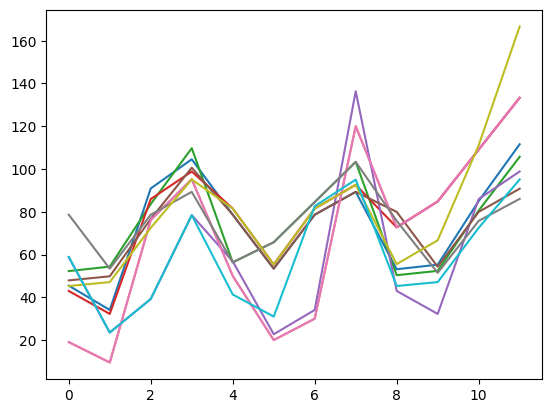

In [13]:
my_df.plot(legend=False)

# Example 3: Monthly flow, using data imported from Excel

The file `oak_creek_monthly_af.xlsx` can be uploaded to Colaboratory and processed using the pandas library.

Given a sequence of monthly streamflow data and 5 synthetic sequences of 5 years of annual flow, use the Nowak disaggregation method to create 10 replicates each of each simulated annual sequence.

In [ ]:
oak_obs_monthly_df = pd.read_excel('oak_creek_monthly_af.xlsx',
                       sheet_name='Monthly Data',
                       index_col=0)

oak_sim_ann_df = pd.read_excel('oak_creek_monthly_af.xlsx',
                               sheet_name='Simulated Annual',
                               index_col=0)

# convert to np array with shape as below
# shape: sequences in rows; years in columns
oak_sim_ann_flow = np.array(oak_sim_ann_df)

In [ ]:
oak_obs_years = oak_obs_monthly_df.Year.unique()

oak_obs_monthly = oak_obs_monthly_df['Volume (af)'].to_numpy()

# shape: years in rows, monthly values in columns
oak_obs_monthly_mat = oak_obs_monthly.reshape((len(oak_obs_years), 12))

oak_obs_ann_flow = np.sum(oak_obs_monthly_mat, axis=1)

# shape: years in rows, monthly proportions in columns
oak_obs_p = np.zeros((len(oak_obs_years), 12))

# calculate the proportion vector
for i in range(12):
  oak_obs_p[:, i] = oak_obs_monthly_mat[:, i]/oak_obs_ann_flow

In [ ]:
# reset the random number generator to produce consistent results for this example
oak_rng = np.random.default_rng(seed=42)

oak_sim_monthly = sim_multi_trace(oak_rng, oak_obs_ann_flow,
                                  oak_obs_p, oak_obs_years,
                                  oak_sim_ann_flow,
                                  repl=10, print_results=False)

oak_sim_monthly_df = pd.DataFrame(oak_sim_monthly)

oak_sim_monthly_df.to_excel('oak_sim_monthly.xlsx')

The results of the analysis are stored in `oak_sim_monthly.xlsx`; download it to your machine before exiting your Colab session!

In [ ]:
#quick plot
oak_sim_monthly_df.plot(legend=False)

Ideas for future updates:

*   Improve plotting and explanations of the Excel example

*   Add a spatial example -- refactor functions to refer more generically to aggregated value Z and disaggregated value x

